# Calidad de las bioactividades y filtro de promiscuidad

Composición de las bioactividades por tag y por fuente, y **filtro de
promiscuidad química**: 30 compuestos de `MW < 150 Da` concentran 104 075
relaciones de subestructura, el 12 % de la capa, y hoy ninguna está filtrada
(S3 Fig del paper 2016).

**Decidido (README §7.3): el filtro se aplica.** Este notebook produce
`03_compuestos_promiscuos.csv`, que `huerfanas/` consume vía
`tdr.compuestos_promiscuos()` antes de construir cualquier semilla. Por eso hay
que correrlo **antes** del paso 5 del orden de trabajo.

Fuente: `reproducir_v6/capa_quimica/02_filtro_promiscuidad.py`.

Salidas: `03_bioactividades_por_tag.csv`, `03_promiscuidad_por_compuesto.csv`,
`03_compuestos_promiscuos.csv`, `03_curva_filtrado.csv`, `03_impacto_filtro.csv`.

## Imports

In [1]:
import sys, os
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ.setdefault(_v, "1")          # antes de numpy: un hilo por proceso

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

V4 = "/home/ggiordano/TDR/TDR_2026_v4"
sys.path.insert(0, f"{V4}/comun")
sys.path.insert(0, f"{V4}/analiceDB")
%load_ext autoreload
%autoreload 2
import tdr, nucleo as nf
import funciones_analice as fa              # el .py de esta carpeta

SALIDAS = tdr.out("analiceDB")
FIGURAS = SALIDAS / "figuras"
NB      = "03"                             # numero de este notebook: prefija todo lo que genere
n_core  = 20

plt = tdr.estilo()
SALIDAS

PosixPath('/home/ggiordano/TDR/TDR_2026_v4/gon4/analiceDB_out')

## Datos

In [2]:
datos = tdr.cargar_db(anotaciones=False, cluster_consistent=False)
# Las relaciones de subestructura crudas: la capa guardada ya está clusterizada
# y no conserva el conteo de superestructuras por molécula.
sub, comp = fa.cargar_subestructuras_crudas()
len(datos.bioact), len(sub), len(comp)

· 00_specie_target
· 03_bioactivities_target_compound


(3526999, 868667, 2499020)

## Acondicionamiento

In [3]:
tags = fa.composicion_bioactividades(datos)
print(f"{len(sub)} relaciones de subestructura mapeadas a compuestos")
print(f"criterio: MW < {tdr.MW_PROMISCUIDAD} Da y N_parentales > {tdr.N_PARENTALES_PROMISCUIDAD}")
tags.head(12)

868667 relaciones de subestructura mapeadas a compuestos
criterio: MW < 150 Da y N_parentales > 100


,activity_tag,cluster_consistent,n,pct
0,indeterminate,True,3128054,88.688826
1,positive,True,248457,7.044431
2,negative,True,144461,4.095862
3,inconsistent,True,5827,0.165211
4,negative,False,91,0.002580
5,positive,False,88,0.002495
6,indeterminate,False,19,0.000539
7,inconsistent,False,2,0.000057


## Corrida

In [4]:
# celda de corrida: el ciclo se lee aca
por_compuesto, promiscuos, impacto = fa.promiscuidad_subestructural(sub, comp)
curva = fa.curva_filtrado(por_compuesto, sub)

tags.to_csv(SALIDAS / f"{NB}_bioactividades_por_tag.csv", index=False)
por_compuesto.to_csv(SALIDAS / f"{NB}_promiscuidad_por_compuesto.csv", index=False)
promiscuos.to_csv(SALIDAS / f"{NB}_compuestos_promiscuos.csv", index=False)  # <- lo lee huerfanas/
curva.to_csv(SALIDAS / f"{NB}_curva_filtrado.csv", index=False)
impacto.to_csv(SALIDAS / f"{NB}_impacto_filtro.csv", index=False)
fa.escribir_meta(SALIDAS, NB, notebook="03_calidad_bioactividades.ipynb",
                 params={"mw_max": tdr.MW_PROMISCUIDAD,
                         "n_parentales_min": tdr.N_PARENTALES_PROMISCUIDAD},
                 aplica_filtro=True, consumido_por="huerfanas/")

  meta -> /home/ggiordano/TDR/TDR_2026_v4/gon4/analiceDB_out/03_meta.json


{'notebook': '03_calidad_bioactividades.ipynb',
 'nb': '03',
 'fecha': '2026-09-07 10:16',
 'params': {'mw_max': 150, 'n_parentales_min': 100},
 'n_core': None,
 'tablas_db': {'00_specie_target.csv': '2026-06-05',
  '00_specie_target_full.csv': '2026-06-05',
  '01_clusters_fingerprint.csv': '2026-05-13',
  '01_deleted_compounds.csv': '2026-05-13',
  '01_edges_clusters_fingerprint.csv': '2026-05-13',
  '02_clusters_subestructure.csv': '2026-05-13',
  '02_edges_clusters_subestructure.csv': '2026-05-13',
  '03_bioactivities_organism_compound.csv': '2026-06-04',
  '03_bioactivities_target_compound.csv': '2026-08-07',
  '04a_interpro.csv': '2026-06-10',
  '04b_orthomcl.csv': '2026-08-25'},
 'python': '3.12.2',
 'pandas': '2.2.3',
 'aplica_filtro': True,
 'consumido_por': 'huerfanas/'}

# Resultados

In [5]:
tags          = pd.read_csv(SALIDAS / f"{NB}_bioactividades_por_tag.csv")
por_compuesto = pd.read_csv(SALIDAS / f"{NB}_promiscuidad_por_compuesto.csv")
promiscuos    = pd.read_csv(SALIDAS / f"{NB}_compuestos_promiscuos.csv")
curva         = pd.read_csv(SALIDAS / f"{NB}_curva_filtrado.csv")
impacto       = pd.read_csv(SALIDAS / f"{NB}_impacto_filtro.csv")
impacto.T

,0
criterio,MW < 150 y N_parentales > 100
compuestos_filtrados,30
pct_compuestos,0.014557
aristas_filtradas,104075
pct_aristas,11.981001
n_parentales_p99,16.0
mw_mediana_filtrados,129.649374


  figura -> /home/ggiordano/TDR/TDR_2026_v4/gon4/analiceDB_out/figuras/03_f01_bioactividades_por_tag.pdf


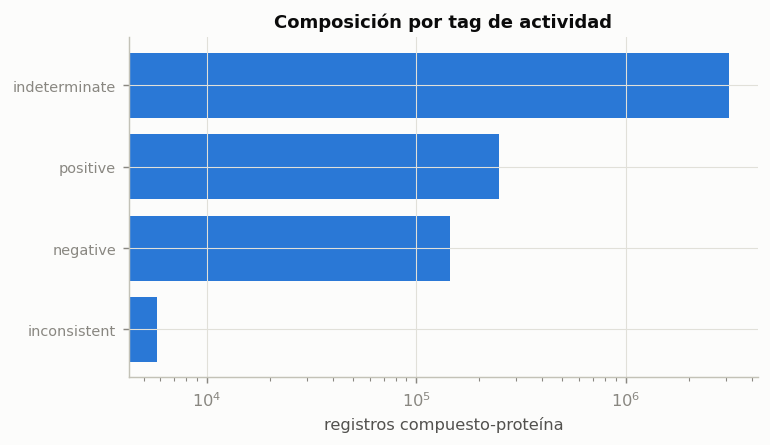

In [6]:
fig, ax = plt.subplots(figsize=(6, 3.5), tight_layout=True)
t = tags.groupby("activity_tag")["n"].sum().sort_values()
ax.barh(range(len(t)), t.values, color=tdr.S1)
ax.set_yticks(range(len(t))); ax.set_yticklabels(t.index, fontsize=8)
ax.set_xscale("log")
ax.set_xlabel("registros compuesto-proteína")
ax.set_title("Composición por tag de actividad")
tdr.guardar(fig, f"{NB}_f01_bioactividades_por_tag", FIGURAS)

  figura -> /home/ggiordano/TDR/TDR_2026_v4/gon4/analiceDB_out/figuras/03_f02_promiscuidad.pdf


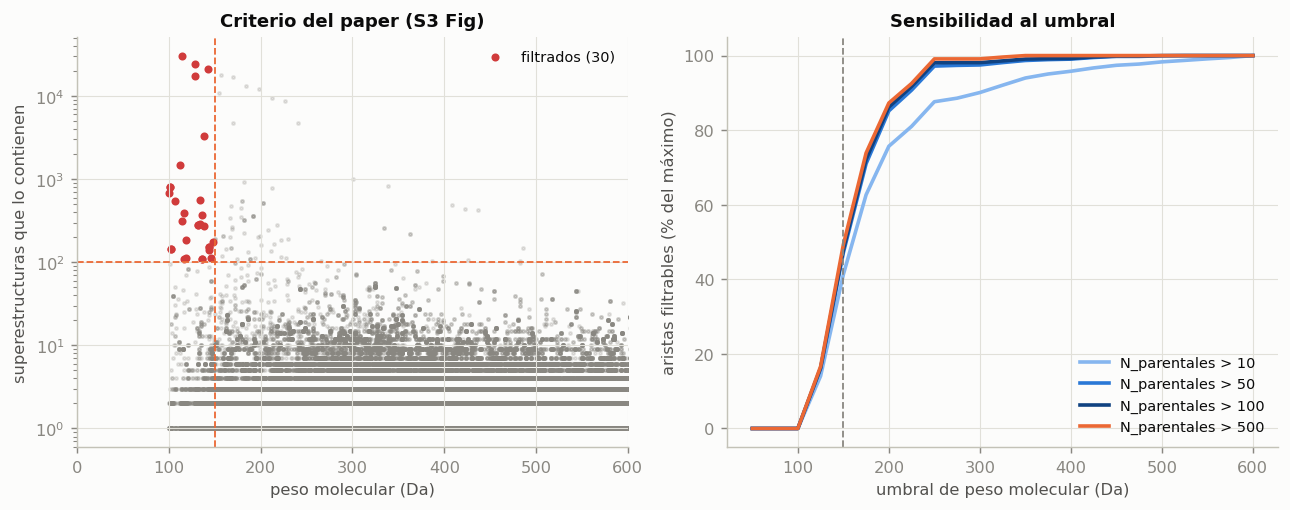

In [7]:
fig = fa.fig_promiscuidad(por_compuesto, curva, plt)
tdr.guardar(fig, f"{NB}_f02_promiscuidad", FIGURAS)

In [8]:
# Los compuestos que se van: es el resultado que condiciona todo lo que viene después
promiscuos.head(30)

,drug_id,n_parentales,molweight
0,166536,30584,114.140851
1,1116907,24544,128.156501
2,163058,21196,142.172151
3,441659,17222,128.062600
4,455761,3316,138.068080
5,1727476,1458,112.125201
6,948280,797,101.120449
7,948280,797,101.120449
8,164281,689,100.125201
9,92057,562,134.094294
